#### QUESTION 1

Overview:

In [32]:
%pip install gdown
import gdown

file_id = "1qOsO1ocP9WT0pK1CMK2EDNlmqemSZID8"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset.csv", quiet=False)

Note: you may need to restart the kernel to use updated packages.


Downloading...
From: https://drive.google.com/uc?id=1qOsO1ocP9WT0pK1CMK2EDNlmqemSZID8
To: /Users/effiewu0628/Desktop/grad_quarter2/ece219/ECE219P1/dataset.csv
100%|██████████| 14.5M/14.5M [00:00<00:00, 41.2MB/s]


'dataset.csv'

In [33]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()
df.shape

(3476, 8)

Overview: The dataset contains 3476 rows and 8 features.

Histogram (a): The total number of alpha-numeric characters per data point in the feature full_text

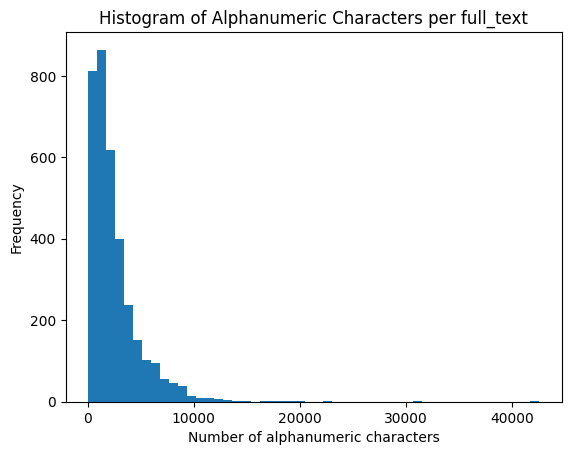

In [34]:
import re

def count_alnum(text):
    return len(re.findall(r"[A-Za-z0-9]", str(text)))

df["alnum_count"] = df["full_text"].apply(count_alnum)
df["alnum_count"].head()

import matplotlib.pyplot as plt

plt.hist(df["alnum_count"], bins=50)
plt.xlabel("Number of alphanumeric characters")
plt.ylabel("Frequency")
plt.title("Histogram of Alphanumeric Characters per full_text")
plt.show()

Histogram (b): The column leaf_label - class on the x-axis

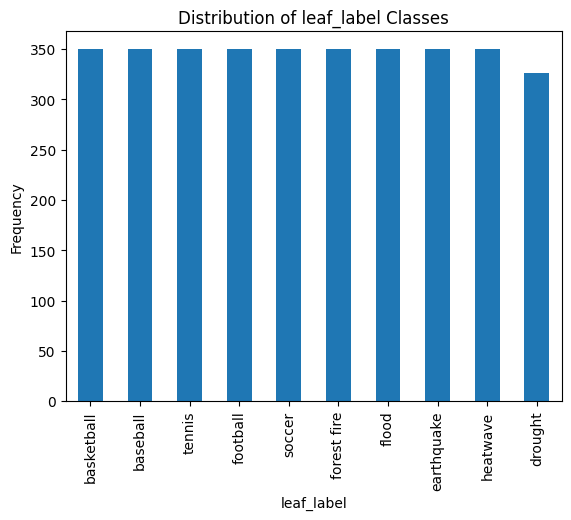

In [35]:
df["leaf_label"].value_counts().plot(kind="bar")
plt.xlabel("leaf_label")
plt.ylabel("Frequency")
plt.title("Distribution of leaf_label Classes")
plt.show()

Histogram (c): The column root_label - class on the x-axis

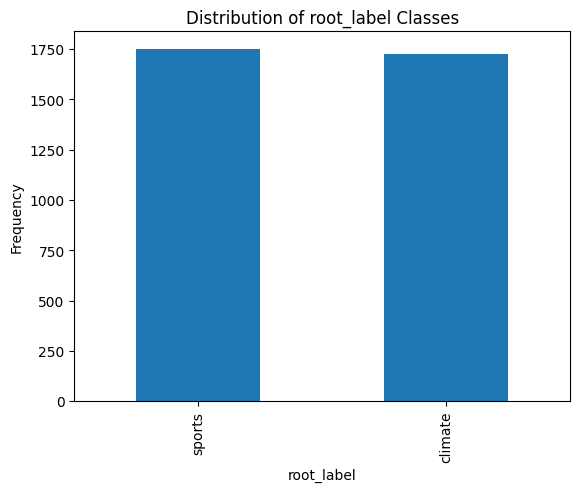

In [36]:
df["root_label"].value_counts().plot(kind="bar")
plt.xlabel("root_label")
plt.ylabel("Frequency")
plt.title("Distribution of root_label Classes")
plt.show()

Histogram interpretations:

Histogram (a): The distribution of alphanumeric character counts in full_text is right-skewed, indicating that most text samples are relatively short, while a smaller number of samples contain significantly longer text. This suggests variability in article or sentence length, which may affect downstream modeling and may require normalization or truncation.

Histogram (b): The distribution of leaf_label classes is nearly uniform, with most classes containing approximately the same number of samples. This suggests the dataset was intentionally constructed to be balanced at the leaf level, which is beneficial for training and evaluating classification models without bias toward particular classes. A slight deviation is observed for the drought class, which contains marginally fewer samples, likely due to preprocessing or filtering effects.

Histogram (c): The distribution of root_label classes is nearly balanced with samples labeled as sports and climate. This balance arises from the intentional construction of the dataset, in which each root category contains an equal number of leaf-level classes with approximately uniform sample counts. Such balance is advantageous for hierarchical classification tasks, as it prevents bias toward either top-level category during model training and evaluation.

#### QUESTION 2

In [37]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df[["full_text", "root_label", "leaf_label"]],
    test_size=0.2,
    random_state=42
)

print("Number of training samples:", train.shape[0])
print("Number of testing samples:", test.shape[0])

Number of training samples: 2780
Number of testing samples: 696


Using a fixed random seed for reproducibility, the dataset was split into training and testing sets with a test fraction of 0.2. This resulted in 2,780 training samples and 696 testing samples. The same split is reused for both the root-level (binary) and leaf-level (multiclass) classification experiments to ensure consistency across evaluations.

#### QUESTION 3

In [38]:
# import nltk

# nltk.download("punkt")
# nltk.download("punkt_tab")
# nltk.download("averaged_perceptron_tagger")
# nltk.download("averaged_perceptron_tagger_eng")
# nltk.download("wordnet")
# nltk.download("omw-1.4")


In [39]:
# Helper functions

import re
def clean(text):
    text = re.sub(r'^https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    texter = re.sub(r"<br />", " ", text)
    texter = re.sub(r"&quot;", "\"",texter)
    texter = re.sub('&#39;', "\"", texter)
    texter = re.sub('\n', " ", texter)
    texter = re.sub(' u '," you ", texter)
    texter = re.sub('`',"", texter)
    texter = re.sub(' +', ' ', texter)
    texter = re.sub(r"(!)\1+", r"!", texter)
    texter = re.sub(r"(\?)\1+", r"?", texter)
    texter = re.sub('&amp;', 'and', texter)
    texter = re.sub('\r', ' ',texter)
    clean = re.compile('<.*?>')
    texter = texter.encode('ascii', 'ignore').decode('ascii')
    texter = re.sub(clean, '', texter)
    if texter == "":
        texter = ""
    return texter

# Judge if a tag is num
_num_pattern = re.compile(r"^[+-]?(\d+(\.\d*)?|\.\d+)$")
def is_number(text):
    return bool(_num_pattern.match(text)) 

# penn2morphy helper function (speech conversion)
def penn2morphy(penntag):
    """ Converts Penn Treebank tags to WordNet. """
    morphy_tag = {'NN':'n', 'JJ':'a',
                  'VB':'v', 'RB':'r'}
    try:
        return morphy_tag[penntag[:2]]
    except:
        return 'n'


In [40]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline


import nltk

# Core tokenization + tagging
nltk.download("punkt")
nltk.download("punkt_tab") 
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
# Lemmatization
nltk.download("wordnet")
nltk.download("omw-1.4")

# Optional (only if your clean() uses stopwords)
nltk.download("stopwords")


from nltk import word_tokenize, pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def my_tokenizer(doc):
    #Preprocessing with clean
    doc = clean(doc)
    tokens = word_tokenize(doc)
    tagged = pos_tag(tokens)

    #remove numbers:
    out = []
    for word, tag in tagged:
        word = word.lower()
        if is_number(word):
            continue
        if not any(ch.isalnum() for ch in word): #optional, to clean the punctuations
            continue
        wordnet_tag = penn2morphy(tag)
        lemma = lemmatizer.lemmatize(word, pos=wordnet_tag)
        out.append(lemma)
    return out

count_vect = CountVectorizer(min_df=3, stop_words='english', tokenizer=my_tokenizer)
tfidf_pipeline = Pipeline([
    ("vectorizer", count_vect),
    ("tfidf", TfidfTransformer())   
])
X_train_tfidf = tfidf_pipeline.fit_transform(train["full_text"])
X_test_tfidf = tfidf_pipeline.transform(test["full_text"])

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)
        



[nltk_data] Downloading package punkt to
[nltk_data]     /Users/effiewu0628/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/effiewu0628/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/effiewu0628/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/effiewu0628/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/effiewu0628/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/effiewu0628/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Do

TF-IDF train shape: (2780, 14542)
TF-IDF test shape: (696, 14542)


**Answer**:

**1.** Compared with stemming, which ignores the grammatical roles of a word, lemmatization care about the dictionary form/lemma of words. As a result, it can preserve the semantic meanings more accurate than stemming while more computational heavy due to extra POS tagging and lookup steps. 

**2.** Min_df defines the minimum number of documents a word must appear in to be considered. Larger min_df leads to a smaller TF_IDF matrix, because more infrequent words will be filtered out.

**3.** They should be moved after the lemmatization, more acccurately, it should be removed after POS tagging. Removing tokens before can lead to incomplete sentence structure/grammer and less accurate POS tagging. 

**4.** TF-IDF train shape: (2780, 14542), TF-IDF test  shape: (696, 14542)

#### QUESTION 4

**Answer**:

**(a)** The probabilities themselves cannot capture semantic relationships becasue they will be influenced by high-frequency but non-discriminative words. However, the ratio can cancel out the noise from non-discriminative words thus preserving the correlation between words that reflects their underlying semantic distinctions. 

**(b)** They have the same word embeddings in GloVe, because one word type corresponds to a single vector learned from global co-occurrence statistics. 

**(c)** Expectation(may be need to modify this): $$||GloVE(wife) - GloVE(husband)||_2 < ||GloVE(left) - GloVE(right)||_2  << ||GloVE(wife) - GloVE(orange)||_2$$ 
orange and wife should have the largest diff because they are the most unrelated pair. wife and husband should have the least diff as the contexts in which "left" and "right" appear are more diverse than those in which "wife" and "husband" appear.

**(d)** Lemmatization is preferred because it produces valid word forms that are more likely to appear in GloVE vocabulary, but stemming may generate non-standard tokens that result in out-of-vocabulary embeddings.




#### QUESTION 5

**Answer**:

**(a)** To construct document-level embeddings using GloVe, we first preprocess each document using the tokenizer defined previously. For each token in a document, we look up the corresponding word embedding from the GloVe vocabulary if it exists. Tokens that are not covered by the GloVe vocabulary are ignored. The document embedding is then obtained by averaging the word embeddings within the document, resulting in a single 300-dimensional representation.

In [41]:
# (b)
#Read GloVe
embeddings_dict = {}
dimension_of_glove = 300

with open("glove/glove.6B.300d.txt", "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], "float32")
        embeddings_dict[word] = vector

    

In [42]:
def document_to_glove_embedding(doc, emb_dict, dim=300):
    tokens = my_tokenizer(doc)
    doc_embs = []
    oovs = 0

    for token in tokens:
        vec = emb_dict.get(token)
        if vec is None:
            oovs += 1
        else:
            doc_embs.append(vec)

    # handle empty doc_embs
    if len(doc_embs) == 0:
        glove_doc = np.zeros(dim, dtype=np.float32)
    else:
        glove_doc = np.mean(doc_embs, axis=0).astype(np.float32)

    return len(tokens), oovs, glove_doc


train_oovs = 0
test_oovs = 0
train_token_len = 0
test_token_len = 0

X_train_glove = []
X_test_glove = []

for doc in train["full_text"]:
    token_len, oovs, glove_doc = document_to_glove_embedding(doc, embeddings_dict, dim=300)
    train_oovs += oovs
    train_token_len += token_len
    X_train_glove.append(glove_doc)

X_train_glove = np.vstack(X_train_glove)
train_oov_rate = train_oovs / max(train_token_len, 1)


for doc in test["full_text"]:
    token_len, oovs, glove_doc = document_to_glove_embedding(doc, embeddings_dict, dim=300)
    test_oovs += oovs
    test_token_len += token_len
    X_test_glove.append(glove_doc)

X_test_glove = np.vstack(X_test_glove)
test_oov_rate = test_oovs / max(test_token_len, 1)


print(f"Shape of train embedding matrix: {X_train_glove.shape}")
print(f"Train oov rate: {train_oov_rate}")
print(f"Shape of test embedding matrix: {X_test_glove.shape}")
print(f"Test oov rate: {test_oov_rate}")



    

Shape of train embedding matrix: (2780, 300)
Train oov rate: 0.01804826877690653
Shape of test embedding matrix: (696, 300)
Test oov rate: 0.01812800108679182


#### QUESTION 6

In [43]:
!pip -q install transformers torch

import torch
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"  # allowed example
MAX_LEN = 512   # use 512 for “handling long docs” reporting
BATCH_SIZE = 32 # reduce to 16 if you get OOM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
enc = AutoModel.from_pretrained(MODEL_NAME).to(device)
enc.eval()

@torch.no_grad()
def encode_texts(texts):
    all_vecs = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i:i+BATCH_SIZE]
        inputs = tok(
            batch,
            truncation=True,
            max_length=MAX_LEN,
            padding=True,
            return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = enc(**inputs)

        # mean pooling with attention mask
        mask = inputs["attention_mask"].unsqueeze(-1).type_as(out.last_hidden_state)
        pooled = (out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)

        all_vecs.append(pooled.cpu())

    return torch.cat(all_vecs, dim=0)


/Users/effiewu0628/miniconda3/envs/ece219/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [44]:
# Q2: 2780 rows, test has 696 rows

all_texts = pd.concat([train["full_text"], test["full_text"]], axis=0).astype(str).tolist()

# token lengths without truncation
lengths = []
for i in range(0, len(all_texts), 256):
    batch = all_texts[i:i+256]
    ids = tok(batch, add_special_tokens=True, truncation=False)["input_ids"]
    lengths.extend([len(x) for x in ids])

lengths = np.array(lengths)
frac_truncated = (lengths > MAX_LEN).mean()

print("MAX_LEN =", MAX_LEN)
print("Fraction of documents that would be truncated:", frac_truncated)
print("Average token length:", lengths.mean())
print("95th percentile token length:", np.percentile(lengths, 95))


Token indices sequence length is longer than the specified maximum sequence length for this model (2595 > 512). Running this sequence through the model will result in indexing errors


MAX_LEN = 512
Fraction of documents that would be truncated: 0.48216340621403914
Average token length: 686.117088607595
95th percentile token length: 2012.75


In [45]:
X_train_emb = encode_texts(train["full_text"].astype(str).tolist())
X_test_emb  = encode_texts(test["full_text"].astype(str).tolist())

print("Train embedding matrix shape:", tuple(X_train_emb.shape))
print("Test embedding matrix shape:", tuple(X_test_emb.shape))

embedding_dim = X_train_emb.shape[1]
print("Embedding dimension:", embedding_dim)


Train embedding matrix shape: (2780, 384)
Test embedding matrix shape: (696, 384)
Embedding dimension: 384


**Answer**:

We use a pretrained Transformer encoder, sentence-transformers/all-MiniLM-L6-v2, as a document embedding model to generate fixed-length vector representations for each news article based on the full_text field. Token-level embeddings produced by the encoder are aggregated using mean pooling over non-padded tokens to obtain a single embedding per document.

- **a)** Transformer encoders have a maximum input length of 512 tokens. To handle long documents, we adopt a truncation strategy, where each article is truncated to the first 512 tokens prior to encoding. Under this setting, approximately 48.2% of documents are truncated. The average document length is 686 tokens, and the 95th percentile document length is approximately 2013 tokens, indicating that a substantial portion of the dataset exceeds the model’s maximum input length. Truncation provides a simple and computationally efficient approach while maintaining compatibility with the pretrained encoder.

- **b)** Using the pretrained encoder, we compute document-level embeddings for both the training and testing sets. The resulting embedding matrices have shape (2780, 384) for the training set and (696, 384) for the testing set. The embedding dimension produced by the model is 384.

#### QUESTION 7

##### Q7.1 TF-IDF + LSI (TruncatedSVD)

k=   1  cumulative explained variance=0.0061
k=   5  cumulative explained variance=0.0709
k=  10  cumulative explained variance=0.1146
k=  25  cumulative explained variance=0.1953
k=  50  cumulative explained variance=0.2704
k= 100  cumulative explained variance=0.3584
k= 500  cumulative explained variance=0.6705
k=1000  cumulative explained variance=0.8498


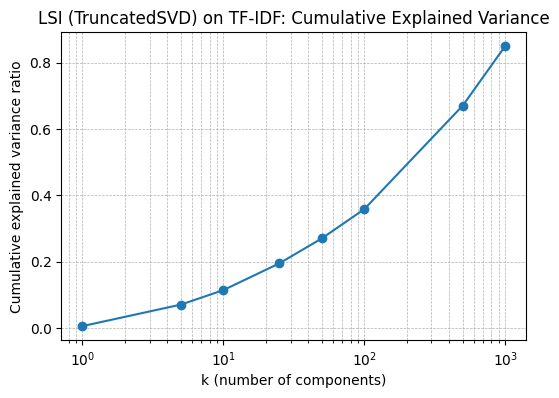

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

k_list = [1, 5, 10, 25, 50, 100, 500, 1000]

cum_var = []
for k in k_list:
    svd = TruncatedSVD(n_components=k, random_state=42)
    svd.fit(X_train_tfidf)
    cum_var.append(svd.explained_variance_ratio_.sum())
    print(f"k={k:4d}  cumulative explained variance={cum_var[-1]:.4f}")

plt.figure(figsize=(6,4))
plt.plot(k_list, cum_var, marker="o")
plt.xscale("log")
plt.xlabel("k (number of components)")
plt.ylabel("Cumulative explained variance ratio")
plt.title("LSI (TruncatedSVD) on TF-IDF: Cumulative Explained Variance")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

In [47]:
k = 25
svd_25 = TruncatedSVD(n_components=k, random_state=42)

X_train_lsi = svd_25.fit_transform(X_train_tfidf)
X_test_lsi  = svd_25.transform(X_test_tfidf)

print("LSI train shape:", X_train_lsi.shape)
print("LSI test  shape:", X_test_lsi.shape)

LSI train shape: (2780, 25)
LSI test  shape: (696, 25)


Q7.1 Answer:

We apply Latent Semantic Indexing (LSI) using Truncated Singular Value Decomposition (TruncatedSVD) on the TF–IDF training matrix and evaluate the cumulative explained variance ratio for different numbers of components $k \in \{1,5,10,25,50,100,500,1000\}$.

The cumulative explained variance increases monotonically with k, reaching approximately 0.195 at k = 25, 0.358 at k = 100, and 0.850 at k = 1000. This indicates that TF–IDF representations are highly high-dimensional and sparse, requiring many components to capture most of the variance. Following the project instructions, we fix k = 25 for subsequent experiments as a reasonable trade-off between dimensionality reduction and information preservation.

Using k=25, the reduced data matrices have the following shapes:

- LSI train matrix: (2780,25)

- LSI test matrix: (696,25)


##### Q7.2 TF-IDF + NMF (k=25) + Reconstruction MSE

In [48]:
from sklearn.decomposition import NMF

k = 25
nmf_25 = NMF(
    n_components=k,
    init="nndsvda",
    random_state=42,
    max_iter=400
)

W_train = nmf_25.fit_transform(X_train_tfidf)   # (n_train, k)
H = nmf_25.components_                          # (k, V)

W_test = nmf_25.transform(X_test_tfidf)         # (n_test, k)

print("NMF train shape:", W_train.shape)
print("NMF test  shape:", W_test.shape)
print("H shape:", H.shape)

NMF train shape: (2780, 25)
NMF test  shape: (696, 25)
H shape: (25, 14542)


In [49]:
from sklearn.metrics import mean_squared_error
from scipy import sparse

def fro_mse(X, X_hat):
    diff = X - X_hat
    n, m = X.shape

    # sparse diff: use sparse power
    if sparse.issparse(diff):
        sq_sum = diff.power(2).sum()

    else:
        # if diff is np.matrix, force ndarray so ** is elementwise
        diff = np.asarray(diff)
        sq_sum = np.sum(diff * diff)

    return float(sq_sum) / (n * m)

# ----- LSI reconstruction on TRAIN -----
# For TruncatedSVD: X_hat ≈ (X @ V^T) @ V
Vt = svd_25.components_              # (k, V)
X_hat_lsi = X_train_lsi @ Vt         # (n_train, V)

mse_lsi = fro_mse(X_train_tfidf, X_hat_lsi)

# ----- NMF reconstruction on TRAIN -----
X_hat_nmf = W_train @ H              # (n_train, V)
mse_nmf = fro_mse(X_train_tfidf, X_hat_nmf)

print("Reconstruction MSE (LSI, k=25):", mse_lsi)
print("Reconstruction MSE (NMF, k=25):", mse_nmf)


Reconstruction MSE (LSI, k=25): 5.3577945938138114e-05
Reconstruction MSE (NMF, k=25): 5.396199624010716e-05


Q7.2 Answer:
We also apply Non-negative Matrix Factorization (NMF) with k = 25 components on the TF–IDF training matrix and transform both training and testing data using the learned factors.

The resulting matrix shapes are:
- NMF train matrix (W): (2780,25)

- NMF test matrix (W_test): (696,25)

- Topic matrix (H): (25,14542)

To compare LSI and NMF, we compute the reconstruction Mean Squared Error (MSE) on the training TF–IDF matrix using the Frobenius norm:
$$MSE = \frac{1}{nm}||X - \hat{X}||^2_F$$

The reconstruction errors are:

- LSI (k=25): $5.36 \times 10^{-5}$

- NMF (k=25): $5.40 \times 10^{-5}$

LSI achieves a slightly lower reconstruction error than NMF at the same rank.

LSI (TruncatedSVD) yields lower reconstruction error because SVD provides the optimal rank-k approximation under the Frobenius norm without constraints. In contrast, NMF imposes non-negativity constraints, which improve interpretability but restrict the solution space, leading to a slightly higher reconstruction error. This behavior is expected and consistent with the theoretical properties of the two methods.

#### QUESTION 8




Hard margin (C=2000)
Accuracy: 0.9468390804597702
Precision: 0.9509536784741145
Recall: 0.9483695652173914
F1: 0.9496598639455782


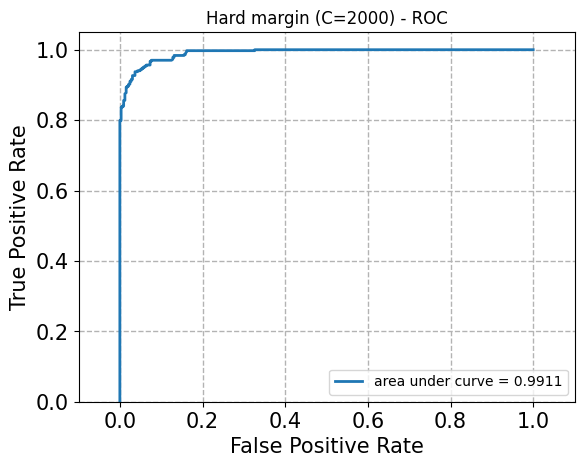

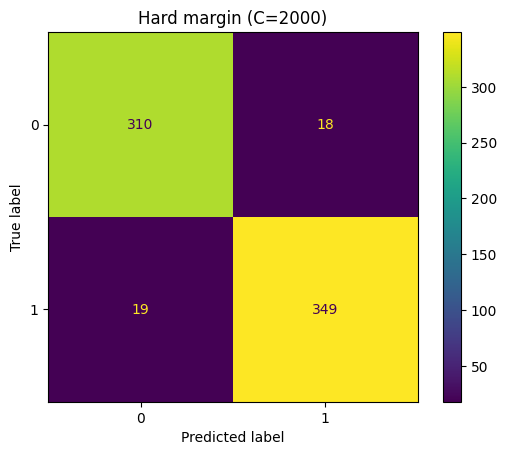


Soft margin (C=0.0005)
Accuracy: 0.9310344827586207
Precision: 0.9301075268817204
Recall: 0.9402173913043478
F1: 0.9351351351351351


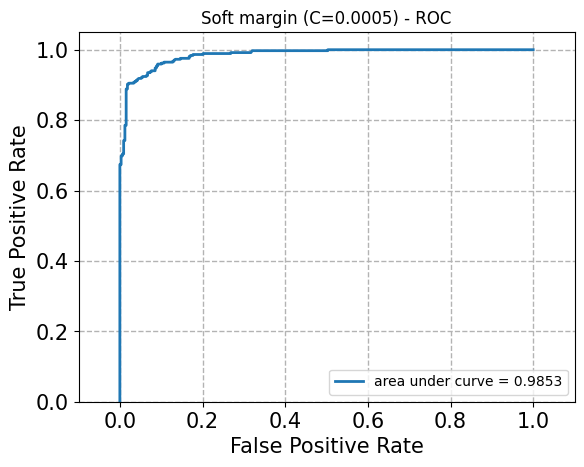

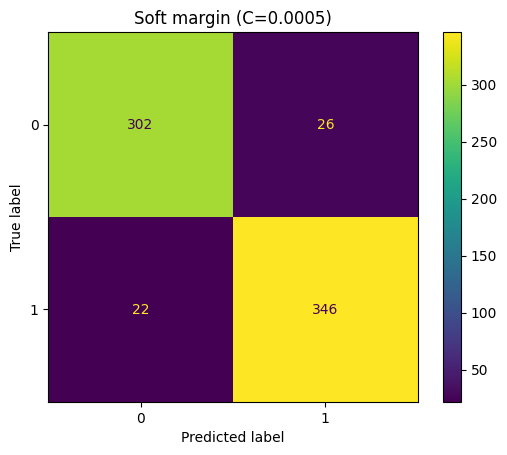


Harder margin (C=100000)
Accuracy: 0.9468390804597702
Precision: 0.9509536784741145
Recall: 0.9483695652173914
F1: 0.9496598639455782


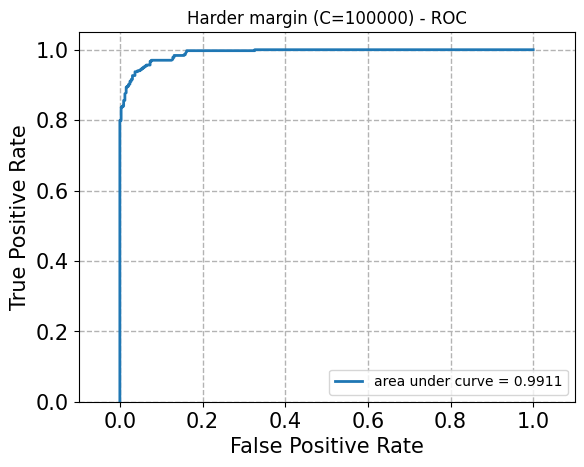

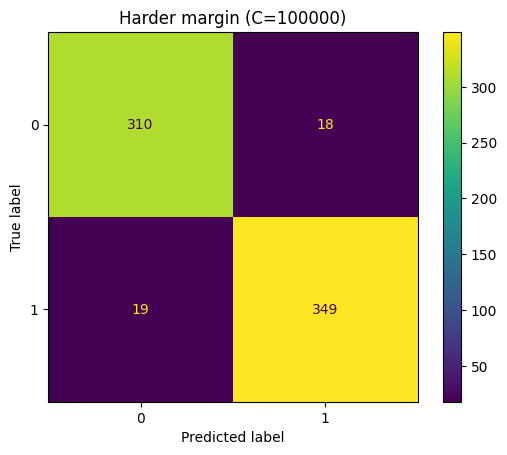

In [67]:
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Q8.1
y_train_svm = (train["root_label"].values == "sports").astype(int)
y_test_svm  = (test["root_label"].values == "sports").astype(int)

# Computer the eval metrics for a particular linear SVM
def eval_svm(X_train, y_train, X_test, y_test, C):
    clf = LinearSVC(C=C, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_score = clf.decision_function(X_test)

    # evaluation 
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    return {
        "cm": cm,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
    }

def plot_roc(fpr, tpr, title=None): # Add title to the original helper function
    fig, ax = plt.subplots()
    plt.grid(True)
    roc_auc = auc(fpr,tpr)

    ax.plot(fpr, tpr, lw=2, label= 'area under curve = %0.4f' % roc_auc)

    ax.grid(color='0.7', linestyle='--', linewidth=1)

    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate',fontsize=15)
    ax.set_ylabel('True Positive Rate',fontsize=15)
    if title:
        ax.set_title(title)

    ax.legend(loc="lower right")

    for label in ax.get_xticklabels()+ax.get_yticklabels():
        label.set_fontsize(15)

hard = eval_svm(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, C=2000)
soft = eval_svm(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, C=0.0005)
harder = eval_svm(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, C=100000)

for name, res in [("Hard margin (C=2000)", hard),
                  ("Soft margin (C=0.0005)", soft),
                  ("Harder margin (C=100000)", harder)]:
    print(f"\n{name}")
    print(f"Accuracy: {res["accuracy"]}")
    print(f"Precision: {res["precision"]}")
    print(f"Recall: {res["recall"]}")
    print(f"F1: {res["f1"]}")
    plot_roc(res["fpr"], res["tpr"], title=name + " - ROC")
    ConfusionMatrixDisplay(res["cm"]).plot()
    plt.title(name)
    plt.show()
    


**Answer(8.1)**:

**(1)** On the test dataset, Hard margin SVM (Accuracy 0.9468, Precision 0.9510, Recall 0.9484, F1 0.9497, AUC 0.991) performs slightly bettern than Soft margin SVM (Accuracy 0.9310, Precision 0.9301, Recall 0.9402, F1 0.9351, AUC 0.985) for all metrics.
When increasing gamma to 100000, we got exactly the same result as the hard margin svm, which indicate that if the classifier has already reached a hard margin solution, increasing of gamma will not change the decision boundary in linear SVMs.

**(2)** For the soft margin SVM, with gamma = 0.0005, the penalty of misclassification is weak. As a result, the margin is too broad and less discriminative.
In the confusion matrix, the number of false positives and false negatives, especially false positives (sports classified as climate), are increased compared with hard margin SVM, leading to lower accuracy, precision, recall and F1 score. Since the positive class (sports) exhibits more consistent feature patterns than the negative class (climate), this relaxation disproportionately increases false positives rather than false negatives.
The ROC curve partially reflects the degraded performance of the soft-margin SVM. because it reflects how well the model ranks positive samples above negative samples, but not its performance at a single fixed threshold.


Best C: 10, with accuracy score: 0.9507194244604318, List:[np.float64(0.9334532374100719), np.float64(0.9345323741007195), np.float64(0.9381294964028777), np.float64(0.9446043165467625), np.float64(0.9507194244604318), np.float64(0.9496402877697843), np.float64(0.95), np.float64(0.9496402877697843), np.float64(0.9496402877697843), np.float64(0.9496402877697843)]

Best SVM on test:
Best C: 10
Accuracy: 0.9425287356321839
Precision: 0.9456521739130435
Recall: 0.9456521739130435
F1: 0.9456521739130435


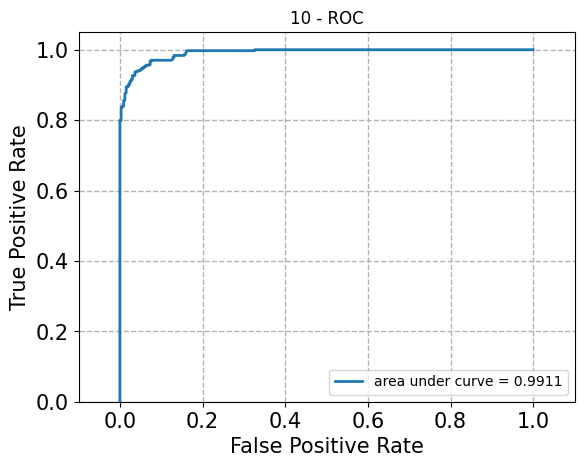

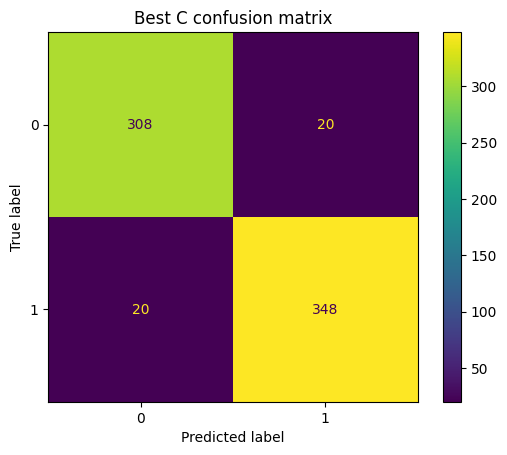

In [72]:
# Q8.2
Cs = [10 ** k for k in range(-3, 7)]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mean_scores = []
for C in Cs:
    clf = LinearSVC(C=C, random_state=42)
    scores = cross_val_score(clf, X_train_lsi, y_train_svm, cv=cv, scoring="accuracy")
    mean_scores.append(np.mean(scores))

best_C = Cs[int(np.argmax(mean_scores))]
best_score = np.max(mean_scores)
print(f"Best C: {best_C}, with accuracy score: {best_score}, List:{mean_scores}")

best_res = eval_svm(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, C=best_C)
print(f"\nBest SVM on test:")
print(f"Best C: {best_C}")
print(f"Accuracy: {best_res['accuracy']}")
print(f"Precision: {best_res['precision']}")
print(f"Recall: {best_res['recall']}")
print(f"F1: {best_res['f1']}")
plot_roc(res["fpr"], res["tpr"], title=str(best_C) + " - ROC")
ConfusionMatrixDisplay(best_res["cm"]).plot()
plt.title("Best C confusion matrix")
plt.show()

    